# Dataset creation (raw CSVs → MongoDB)

End-to-end pipeline that:
1. Discovers raw `acc`/`gyr` CSVs under `data/`.
2. Pairs them by session key, merges on `Epoch` and applies a zero-phase Butterworth lowpass
3. Saves a static 6-axis time-series plot and a 3D acc/gyr scatter per session under `outputs/figures/`.
4. Inserts one merged document per session into the MongoDB collection from `config.yml`.

All heavy lifting lives in `utils.py` and `utils_visual.py` — this notebook is just orchestration.

> **Prerequisite:** MongoDB is running locally (`mongod` service up). On macOS: `brew services start mongodb-community`. On Windows: `net start MongoDB`.


## Setup

In [1]:
import os
from pathlib import Path
from collections import Counter

import yaml
from IPython.display import Image

from utils import (
    discover_csvs, pair_acc_gyr, load_session, build_document,
    mongo_connect, insert_documents,
)
from utils_visual import (
    visualize_all, plot_session_timeseries, plot_session_3d, session_slug,
)

## Load configuration

In [2]:
config_path = os.path.join(os.getcwd(), "config.yml")
with open(config_path) as f:
    config = yaml.safe_load(f)

DATA_DIR    = Path(config["data_path"]).resolve()
FIGURES_DIR = Path(config.get("out_figures", "./outputs/figures")).resolve()
print("data:    ", DATA_DIR)
print("figures: ", FIGURES_DIR)

data:     D:\Documents\GitHub\social-media-gesture-recognition\data
figures:  D:\Documents\GitHub\social-media-gesture-recognition\outputs\figures


## 1. Discover & pair raw CSVs

Each session has **two** raw CSVs (`acc` + `gyr` separately). We pair them by their shared key `(gesture_id, finger, typing_style, hand, primary, user)` — the only field that differs is `sensor`.

In [3]:
csvs = discover_csvs(DATA_DIR)
print(f"Found {len(csvs)} CSV files")

pairs = list(pair_acc_gyr(csvs))
print(f"Paired {len(pairs)} sessions (expecting 27 = 9 gesture×variant × 3 users)")

# Quick sanity: balance per (gesture, user)
Counter((m["gesture_id"], m["user"]) for m, _, _ in pairs)

Found 54 CSV files
Paired 27 sessions (expecting 27 = 9 gesture×variant × 3 users)


Counter({('scroll-down', 'a'): 2,
         ('scroll-down', 'b'): 2,
         ('scroll-down', 's'): 2,
         ('scroll-up', 'a'): 2,
         ('scroll-up', 'b'): 2,
         ('scroll-up', 's'): 2,
         ('swipe-left', 'a'): 2,
         ('swipe-left', 'b'): 2,
         ('swipe-left', 's'): 2,
         ('swipe-right', 'a'): 2,
         ('swipe-right', 'b'): 2,
         ('swipe-right', 's'): 2,
         ('texting', 'a'): 1,
         ('texting', 'b'): 1,
         ('texting', 's'): 1})

## 2. Load + merge + filter

Each pair is loaded, joined on `Epoch` with a 10 ms tolerance, and lowpass-filtered (Butterworth, order 4, fc=10 Hz @ fs=100 Hz). The result is one 6-axis DataFrame per session.

In [4]:
sessions = [(load_session(acc, gyr), meta) for meta, acc, gyr in pairs]
print(f"Loaded {len(sessions)} merged sessions")

# Quick sanity on the first one
df0, meta0 = sessions[0]
print(f"First session: {meta0['gesture_id']} / {meta0['finger']} / user={meta0['user']}  shape={df0.shape}")
df0.head()

Loaded 27 merged sessions
First session: scroll-down / index / user=a  shape=(15149, 7)


,Epoch,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
0,1777373011386,-0.268045,0.268433,0.951895,0.082422,0.238929,0.130590
1,1777373011388,-0.302099,0.284303,0.941326,0.081418,0.237963,0.133175
2,1777373011388,-0.331538,0.297509,0.931981,0.080425,0.234738,0.137168
3,1777373011388,-0.353450,0.306101,0.924782,0.079371,0.227113,0.143251
4,1777373011390,-0.367495,0.309458,0.920067,0.078168,0.213642,0.150962


## 3. Save static figures (one per session × 2 plot types)

In [5]:
n_viz = visualize_all(sessions, FIGURES_DIR)
print(f"Wrote {n_viz * 2} PNGs to {FIGURES_DIR}")

Wrote 54 PNGs to D:\Documents\GitHub\social-media-gesture-recognition\outputs\figures


Inline preview of one session:

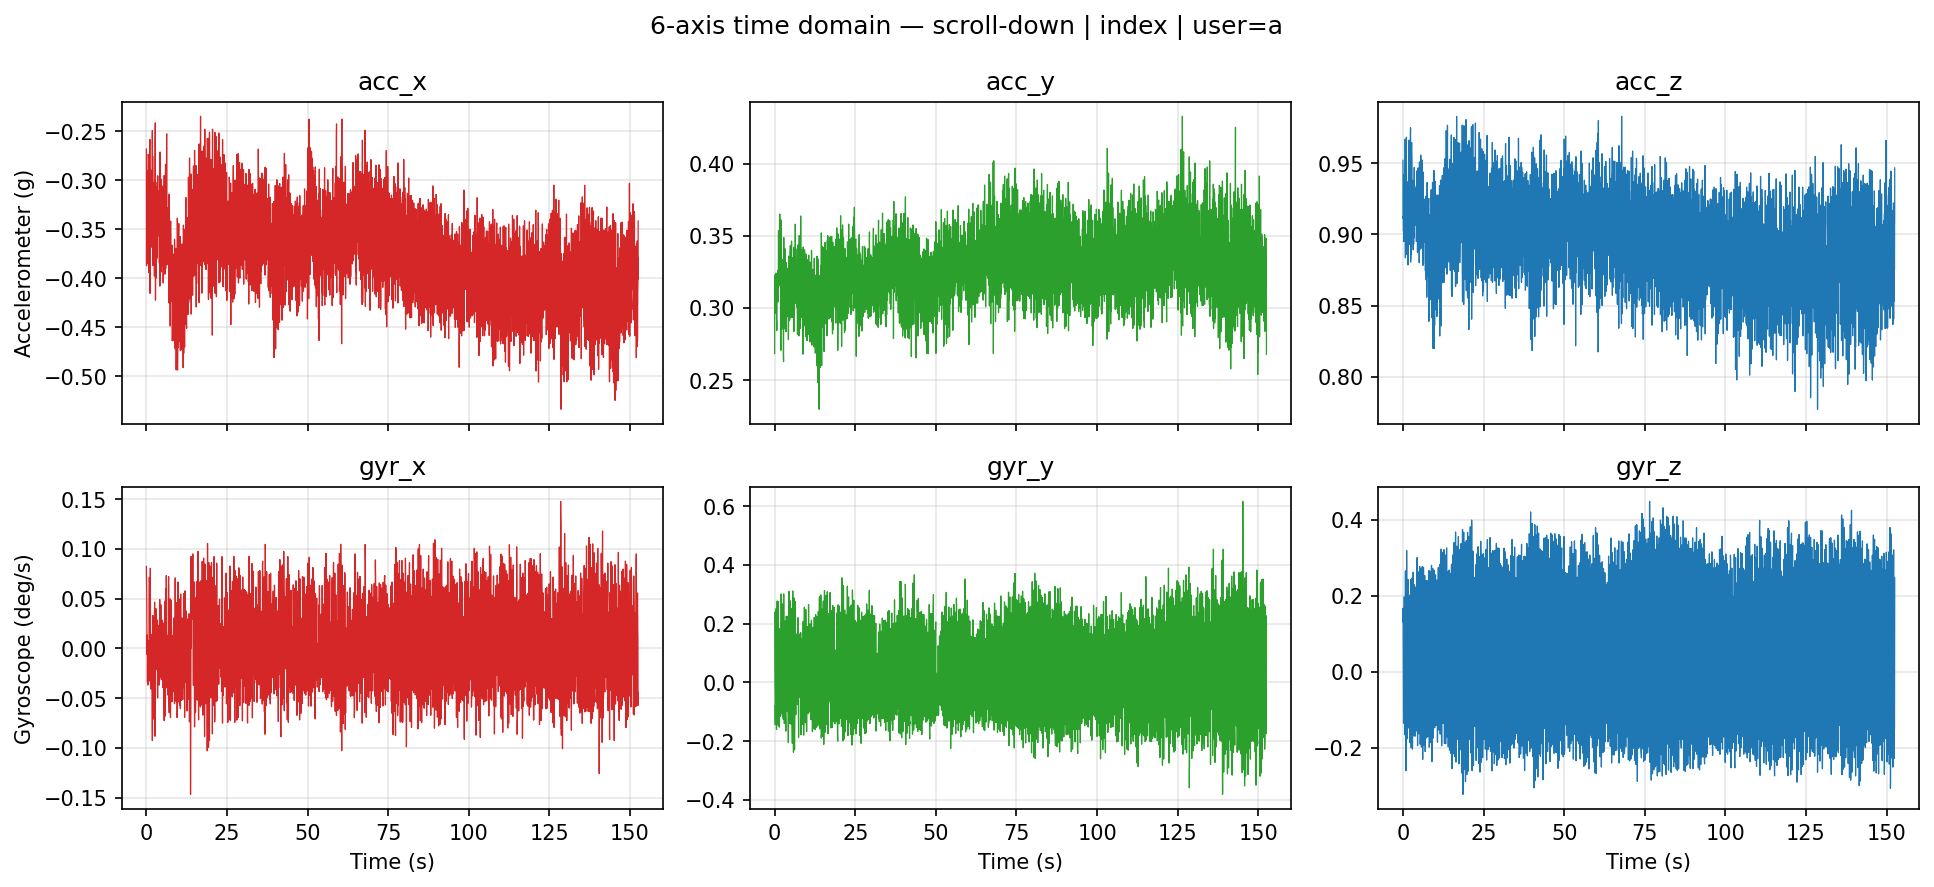

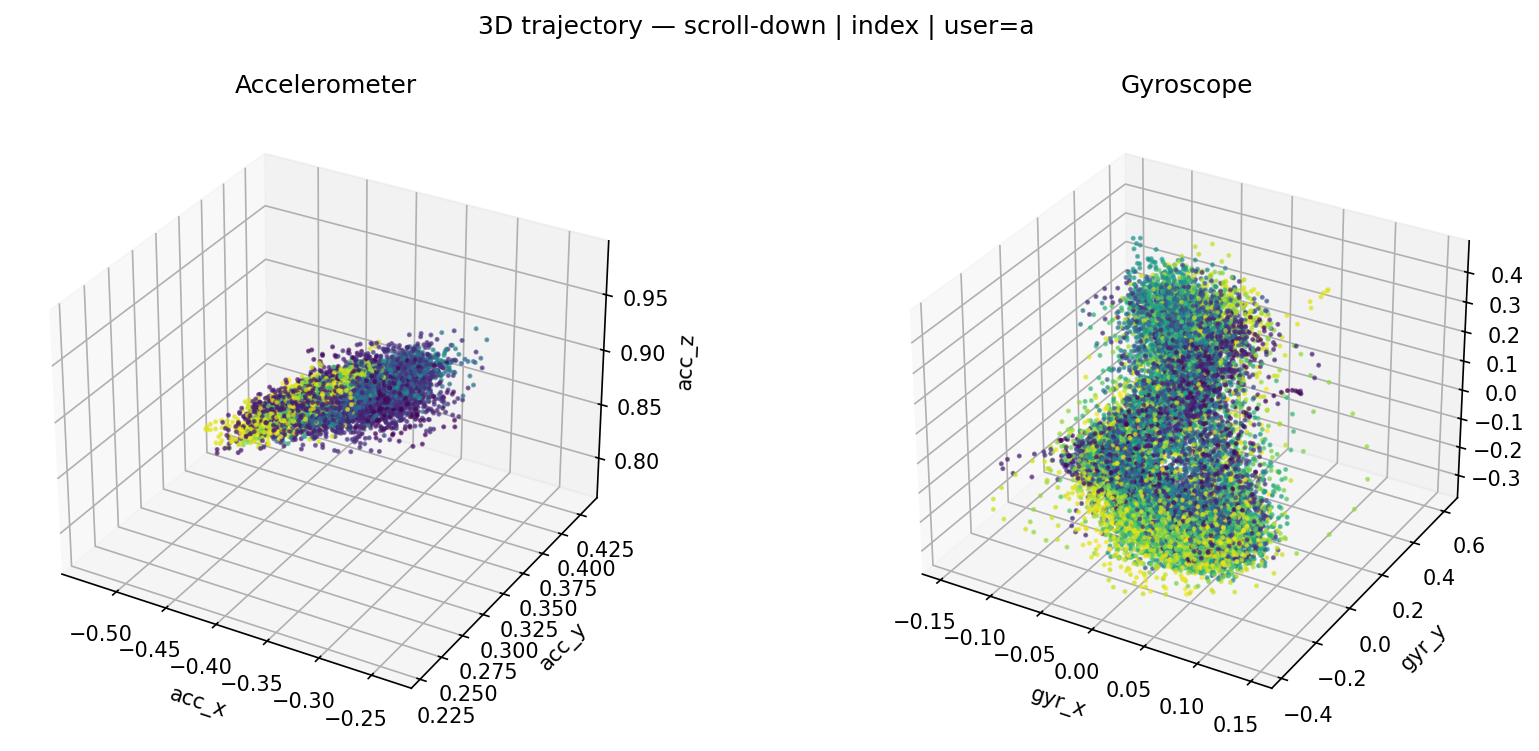

In [6]:
preview_df, preview_meta = sessions[0]
preview_ts = plot_session_timeseries(preview_df, preview_meta, FIGURES_DIR)
preview_3d = plot_session_3d(preview_df, preview_meta, FIGURES_DIR)
display(Image(filename=str(preview_ts)))
display(Image(filename=str(preview_3d)))

## 4. Insert into MongoDB

`mongo_connect(reset=True)` clears existing documents in the collection (idempotent re-run) and creates a unique index on `session_id`.

In [7]:
coll = mongo_connect(uri=config["client"], db=config["db"], collection=config["col"], reset=True)
print(f"Connected to {coll.full_name}")

docs = (build_document(df, meta) for df, meta in sessions)
n_ins = insert_documents(coll, docs)
print(f"Inserted {n_ins} documents")

Connected to IoTSocial.sensor_data
Inserted 27 documents


## 5. Verification

In [8]:
assert coll.count_documents({}) == len(sessions), "Document count mismatch"

# Count per gesture
from collections import Counter
gestures = Counter(d["gesture_id"] for d in coll.find({}, {"gesture_id": 1}))
print("Per gesture:", dict(gestures))

# Inspect one document (without the heavy `data` field)
sample = coll.find_one({}, {"data": 0})
sample

Per gesture: {'scroll-down': 6, 'scroll-up': 6, 'swipe-left': 6, 'swipe-right': 6, 'texting': 3}


{'_id': ObjectId('69f99e81faf03b94f1e97aa0'),
 'session_id': 'd61bd8afe618e0ba879de3e0',
 'gesture_id': 'scroll-down',
 'finger': 'index',
 'typing_style': 'na',
 'hand': 0,
 'sr': 100,
 'sensor': 'AccGyr',
 'primary': 0,
 'spontaneous': 0,
 'user': 'a',
 'datetime': datetime.datetime(2026, 5, 5, 7, 38, 41, 863000)}